# Lab 04 — Feature Extraction, Filtering & Convolution, Edge Detection (AI-4002)
| Section | What's inside |
|---|---|
| 0 | Setup — sample image + wood / metal / fabric textures in `data/` |
| A | Histogram-based features: **HOG · LBP · Color histogram · HED · HIG · Texture energy & contrast** |
| B | Filtering & convolution: box, Gaussian, Sobel, Scharr, emboss · convolution from scratch · **valid / same / strided** |
| C | Edge detection: Sobel+threshold, Prewitt, Scharr, LoG, **Canny** (+ parameter effects) |
| D | Corner detection (Harris, Shi-Tomasi) — listed in objectives |
| E | **Manual Task:** Texture analysis for material classification (code + description) |

## 0. Setup

In [1]:
import os, cv2, numpy as np, matplotlib.pyplot as plt
from skimage import data
os.makedirs('data', exist_ok=True)
if not os.path.exists('data/image.jpg'):
    cv2.imwrite('data/image.jpg', data.camera())
rng = np.random.default_rng(0)
yy, xx = np.mgrid[0:256, 0:256].astype(np.float32)
if not os.path.exists('data/wood.png'):
    warp_ = cv2.GaussianBlur(rng.normal(0, 1, (256, 256)).astype(np.float32), (0, 0), 12) * 40
    wood = 120 + 60 * np.sin((xx + warp_) / 6.0) + rng.normal(0, 6, (256, 256))
    metal = cv2.blur(rng.normal(150, 40, (256, 256)).astype(np.float32), (41, 1)) + yy * 0.15   # brushed streaks
    fabric = 128 + 50 * np.sign(np.sin(xx / 3.0)) * np.sign(np.sin(yy / 3.0)) + rng.normal(0, 15, (256, 256))  # weave
    for n, t in [('wood', wood), ('metal', metal), ('fabric', fabric)]:
        cv2.imwrite(f'data/{n}.png', np.clip(t, 0, 255).astype(np.uint8))
print(os.listdir('data'))

def show(images, titles, cols=None, size=4, cmap='gray'):
    cols = cols or len(images); rows = int(np.ceil(len(images) / cols))
    fig, ax = plt.subplots(rows, cols, figsize=(size * cols, size * rows)); ax = np.array(ax).ravel()
    for a in ax: a.axis('off')
    for a, im, t in zip(ax, images, titles): a.imshow(im, cmap=cmap if im.ndim == 2 else None); a.set_title(t)
    plt.tight_layout(); plt.show()

['fabric.png', 'image.jpg', 'metal.png', 'wood.png']


# A. Histogram-based feature extraction
**Local features** (keypoints, corners, patches → matching, detection) vs **Global features** (whole image → color histograms, texture descriptors, moments).
## A1. HOG — Histogram of Oriented Gradients (object & pedestrian detection)
Steps: grayscale → gradient magnitude & orientation (Sobel) → **8×8 cells** → orientation histogram per cell → **2×2 block normalization** (lighting) → concatenate = feature vector.

HOG feature vector length: (142884,)


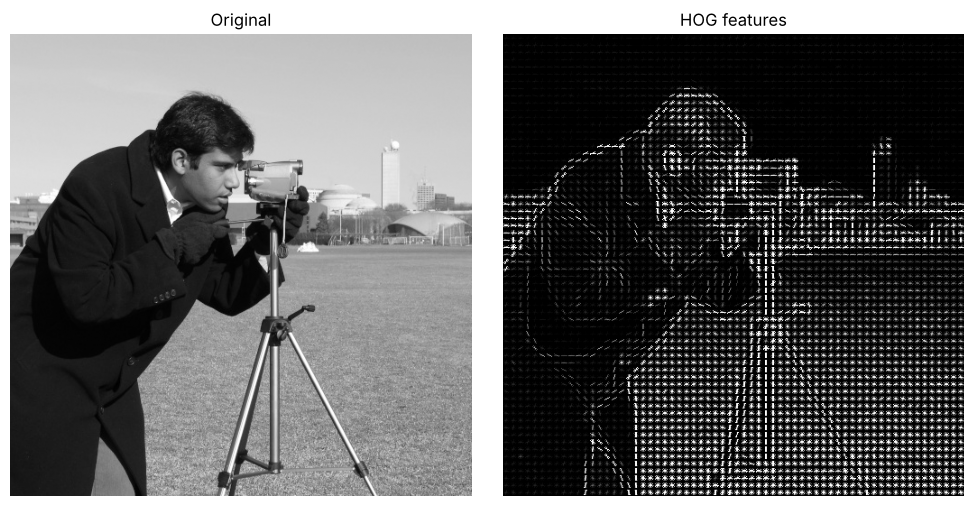

In [2]:
from skimage.feature import hog
from skimage import exposure
image = cv2.imread('data/image.jpg', cv2.IMREAD_GRAYSCALE)
if image is None: raise FileNotFoundError('data/image.jpg')

features, hog_image = hog(image, orientations=9, pixels_per_cell=(8, 8), cells_per_block=(2, 2), visualize=True)
hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10))
print('HOG feature vector length:', features.shape)        # (63*63 blocks * 2*2 cells * 9 bins) for 512x512
show([image, hog_image_rescaled], ['Original', 'HOG features'], size=5)

## A2. LBP — Local Binary Pattern (texture classification, face recognition)
Neighbour ≥ centre → 1 else 0 → read bits as a binary number → histogram of codes = feature vector.
P = 8·radius neighbours; `method='uniform'` gives P+2 bins.

neighbours: [6, 5, 2, 1, 7, 8, 9, 7] -> bits [1, 0, 0, 0, 1, 1, 1, 1] -> LBP code = 143
LBP feature vector: [0.056 0.072 0.034 0.083 0.094 0.13  0.061 0.094 0.238 0.138]


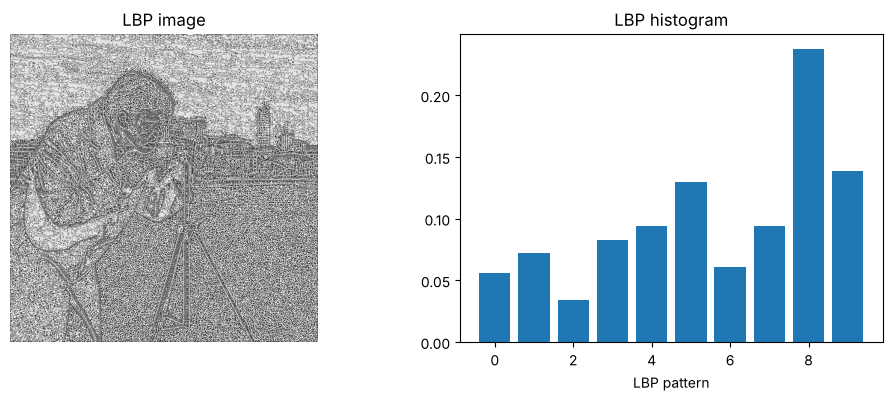

In [3]:
from skimage import feature
# worked example on one 3x3 patch
patch = np.array([[6, 5, 2], [7, 6, 1], [9, 8, 7]])
c = patch[1, 1]
order = [int(v) for v in (patch[0,0], patch[0,1], patch[0,2], patch[1,2], patch[2,2], patch[2,1], patch[2,0], patch[1,0])]  # clockwise from top-left
bits = [1 if v >= c else 0 for v in order]
print('neighbours:', order, '-> bits', bits, '-> LBP code =', int(''.join(map(str, bits)), 2))

radius = 1
n_points = 8 * radius
lbp_image = feature.local_binary_pattern(image, n_points, radius, method='uniform')
hist, _ = np.histogram(lbp_image.ravel(), bins=np.arange(0, n_points + 3), range=(0, n_points + 2))
hist = hist.astype('float'); hist /= (hist.sum() + 1e-6)           # normalize
print('LBP feature vector:', hist.round(3))
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].imshow(lbp_image, cmap='gray'); ax[0].set_title('LBP image'); ax[0].axis('off')
ax[1].bar(range(0, n_points + 2), hist); ax[1].set_title('LBP histogram'); ax[1].set_xlabel('LBP pattern')
plt.show()

## A3. Color histogram — distribution of color intensities (bins in RGB or HSV)

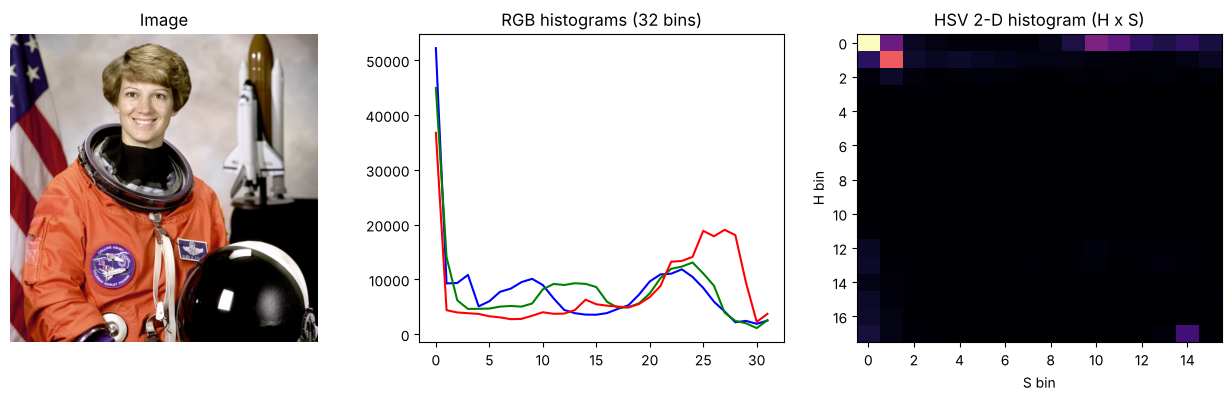

color feature length: (288,)


In [4]:
color = cv2.cvtColor(data.astronaut(), cv2.COLOR_RGB2BGR)
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
ax[0].imshow(cv2.cvtColor(color, cv2.COLOR_BGR2RGB)); ax[0].axis('off'); ax[0].set_title('Image')
for i, col in enumerate(['b', 'g', 'r']):
    h = cv2.calcHist([color], [i], None, [32], [0, 256])         # 32 bins per channel
    ax[1].plot(h, color=col)
ax[1].set_title('RGB histograms (32 bins)')
hsv = cv2.cvtColor(color, cv2.COLOR_BGR2HSV)
h2d = cv2.calcHist([hsv], [0, 1], None, [18, 16], [0, 180, 0, 256])   # Hue x Saturation
ax[2].imshow(h2d, aspect='auto', cmap='magma'); ax[2].set_title('HSV 2-D histogram (H x S)'); ax[2].set_xlabel('S bin'); ax[2].set_ylabel('H bin')
plt.show()
color_feature = cv2.normalize(h2d, None).flatten()
print('color feature length:', color_feature.shape)

## A4. HED — Histogram of Edge Directions
Gray (+Gaussian) → edge map (Canny/Sobel) → orientation θ = arctan2(gy, gx) → bin (e.g. 360° into 8 bins) → histogram.

HED feature vector: [2847 3034 3170 3051 2893 3070 3272 3252]


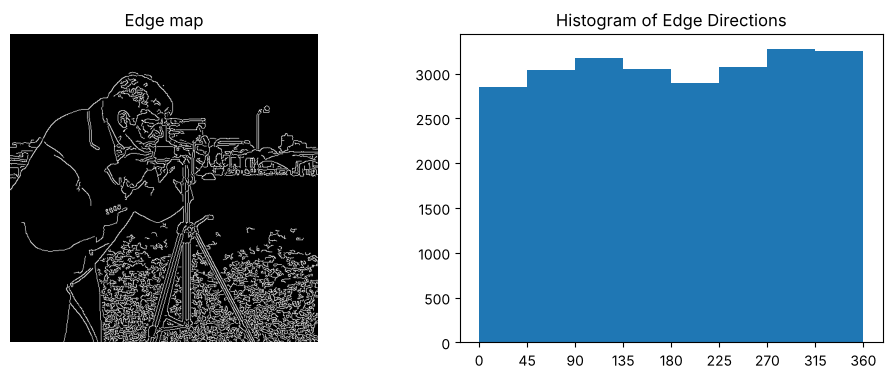

In [5]:
image_smoothed = cv2.GaussianBlur(image, (5, 5), 0)
edges = cv2.Canny(image_smoothed, threshold1=30, threshold2=70)
gx = cv2.Sobel(image_smoothed, cv2.CV_64F, 1, 0, ksize=3)
gy = cv2.Sobel(image_smoothed, cv2.CV_64F, 0, 1, ksize=3)
orientation = (np.degrees(np.arctan2(gy, gx)) + 360) % 360          # 0..360
hed, bin_edges = np.histogram(orientation[edges > 0], bins=8, range=(0, 360))   # only edge pixels
print('HED feature vector:', hed)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].imshow(edges, cmap='gray'); ax[0].set_title('Edge map'); ax[0].axis('off')
ax[1].bar(bin_edges[:-1], hed, width=45, align='edge'); ax[1].set_xticks(range(0, 361, 45)); ax[1].set_title('Histogram of Edge Directions')
plt.show()

## A5. HIG — Histogram of Intensity Gradients
Magnitude **G = √(dx² + dy²)**, orientation **θ = atan2(dy, dx)** → histogram of orientations (optionally normalised → scale-invariant).

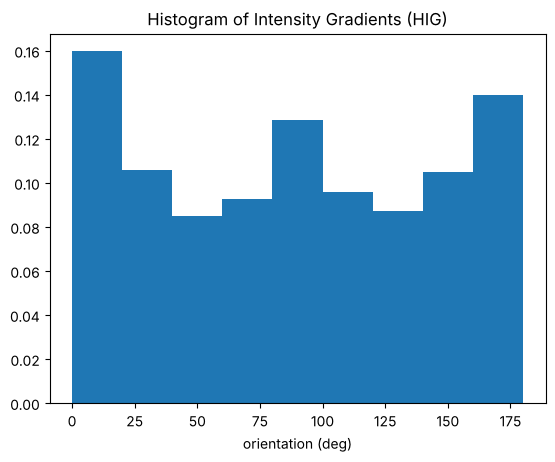

HIG feature vector: [0.16  0.106 0.085 0.093 0.129 0.096 0.087 0.105 0.14 ]


In [6]:
dx = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)
dy = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)
magnitude = np.sqrt(dx**2 + dy**2)
orientation = np.arctan2(dy, dx) * (180 / np.pi)           # -180..180
histogram, bins = np.histogram(np.abs(orientation), bins=9, range=(0, 180), weights=magnitude)   # magnitude-weighted
histogram = histogram / histogram.sum()
plt.bar(bins[:-1], histogram, width=20, align='edge'); plt.title('Histogram of Intensity Gradients (HIG)'); plt.xlabel('orientation (deg)'); plt.show()
print('HIG feature vector:', histogram.round(3))

## A6. Texture energy & contrast histograms (window 3×3 or 5×5)
* **Energy E = Σ (pixel values)²** in the neighbourhood (manual: higher → more complex, less uniform texture).
* **Contrast C = √Var(pixel values)** = local standard deviation (higher → more variation).
> Manual code fixes: convert to **float** first (`image**2` on uint8 overflows) and compute contrast as a real standard deviation.

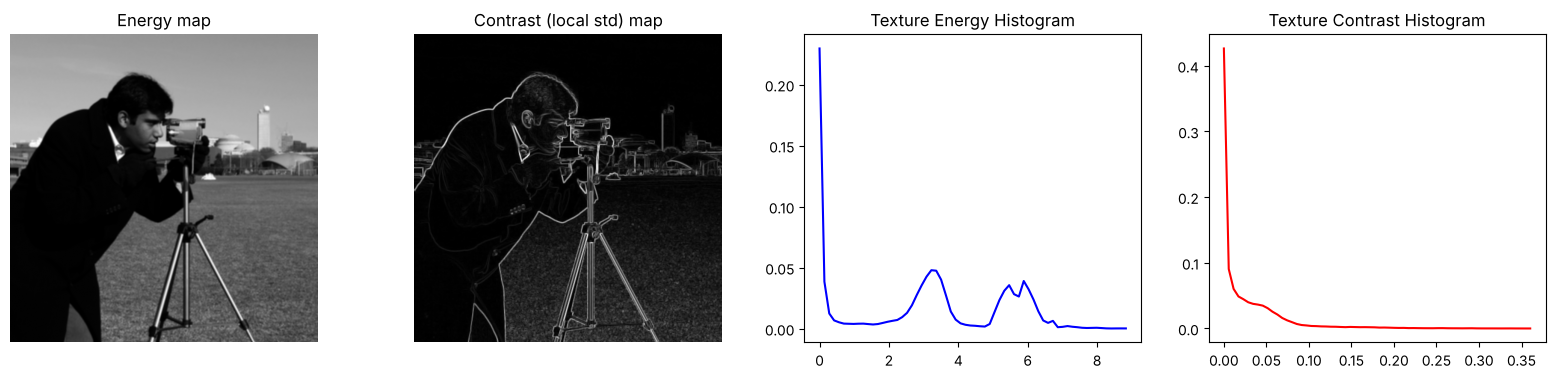

In [7]:
def texture_energy_contrast(gray, k=3):
    f = gray.astype(np.float64) / 255.0
    energy = cv2.filter2D(f ** 2, -1, np.ones((k, k)))                # sum of squares in window
    mean = cv2.blur(f, (k, k)); mean_sq = cv2.blur(f ** 2, (k, k))
    contrast = np.sqrt(np.maximum(mean_sq - mean ** 2, 0))            # local std = sqrt(Var)
    return energy, contrast

energy, contrast = texture_energy_contrast(image, 3)
eh, eb = np.histogram(energy, bins=64, range=(0, energy.max())); ch, cb = np.histogram(contrast, bins=64, range=(0, contrast.max()))
fig, ax = plt.subplots(1, 4, figsize=(20, 4))
ax[0].imshow(energy, cmap='gray'); ax[0].set_title('Energy map'); ax[1].imshow(contrast, cmap='gray'); ax[1].set_title('Contrast (local std) map')
ax[2].plot(eb[:-1], eh / eh.sum(), 'b'); ax[2].set_title('Texture Energy Histogram'); ax[3].plot(cb[:-1], ch / ch.sum(), 'r'); ax[3].set_title('Texture Contrast Histogram')
ax[0].axis('off'); ax[1].axis('off'); plt.show()

# B. Filtering & Convolution
Convolution = slide kernel, **element-wise multiply, sum** (dot product), write to output pixel.
`cv2.filter2D` actually computes **correlation** (kernel not flipped) — identical for symmetric kernels.

5x5 Gaussian kernel:
 [[0.003 0.013 0.022 0.013 0.003]
 [0.013 0.06  0.098 0.06  0.013]
 [0.022 0.098 0.162 0.098 0.022]
 [0.013 0.06  0.098 0.06  0.013]
 [0.003 0.013 0.022 0.013 0.003]]


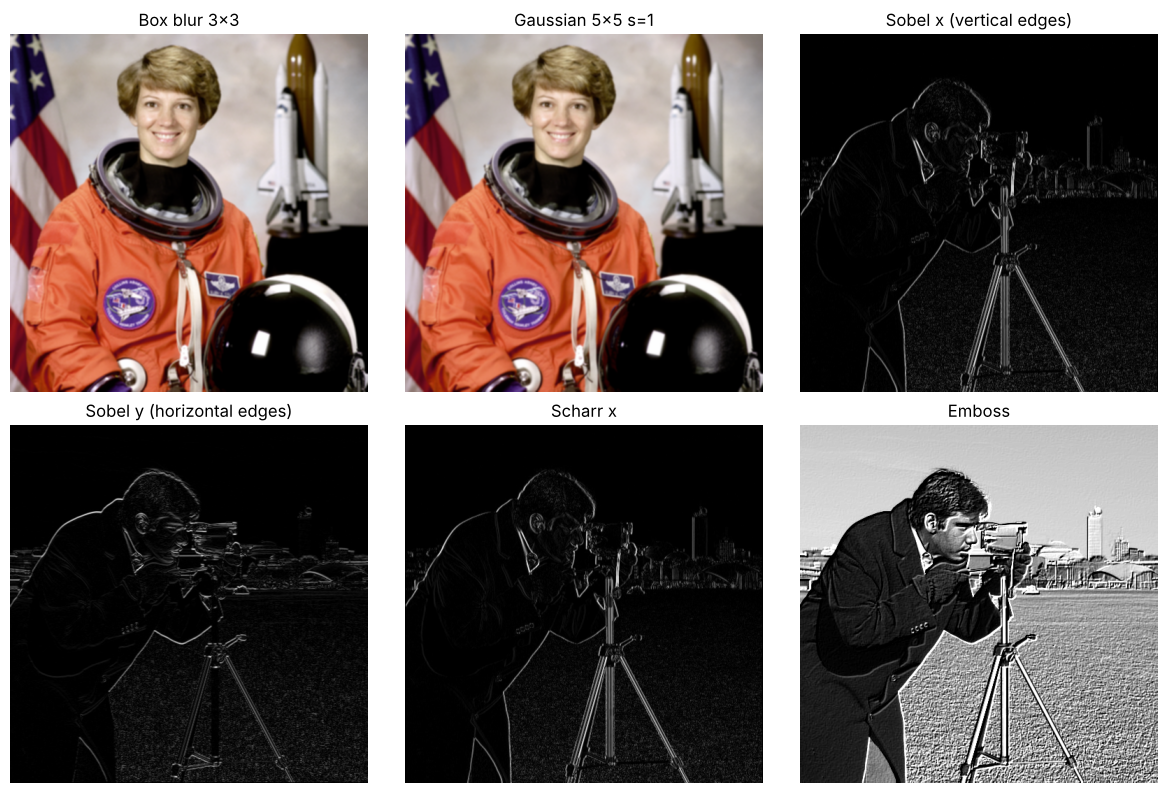

In [8]:
color_img = cv2.cvtColor(data.astronaut(), cv2.COLOR_RGB2BGR)
box = cv2.filter2D(color_img, -1, np.ones((3, 3), np.float32) / 9)                  # box blur (average)
g1d = cv2.getGaussianKernel(5, 1.0)                                                 # 5x1 column
gauss = cv2.filter2D(color_img, -1, g1d @ g1d.T)                                    # outer product -> 5x5 kernel
sobel_x = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3); sobel_y = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)
scharr_x = cv2.Scharr(image, cv2.CV_64F, 1, 0)
emboss = cv2.filter2D(image, -1, np.array([[-2, -1, 0], [-1, 1, 1], [0, 1, 2]], np.float32))
print('5x5 Gaussian kernel:\n', (g1d @ g1d.T).round(3))
show([cv2.cvtColor(box, cv2.COLOR_BGR2RGB), cv2.cvtColor(gauss, cv2.COLOR_BGR2RGB), np.abs(sobel_x), np.abs(sobel_y), np.abs(scharr_x), emboss],
     ['Box blur 3x3', 'Gaussian 5x5 s=1', 'Sobel x (vertical edges)', 'Sobel y (horizontal edges)', 'Scharr x', 'Emboss'], cols=3)

input (64, 64) | valid (62, 62) | same (64, 64) | valid+stride 2 (31, 31)
formula: out = (N - K + 2P) / S + 1  ->  (64-3+0)/2+1 = 31
filter2D (correlation) == conv with flipped kernel: True


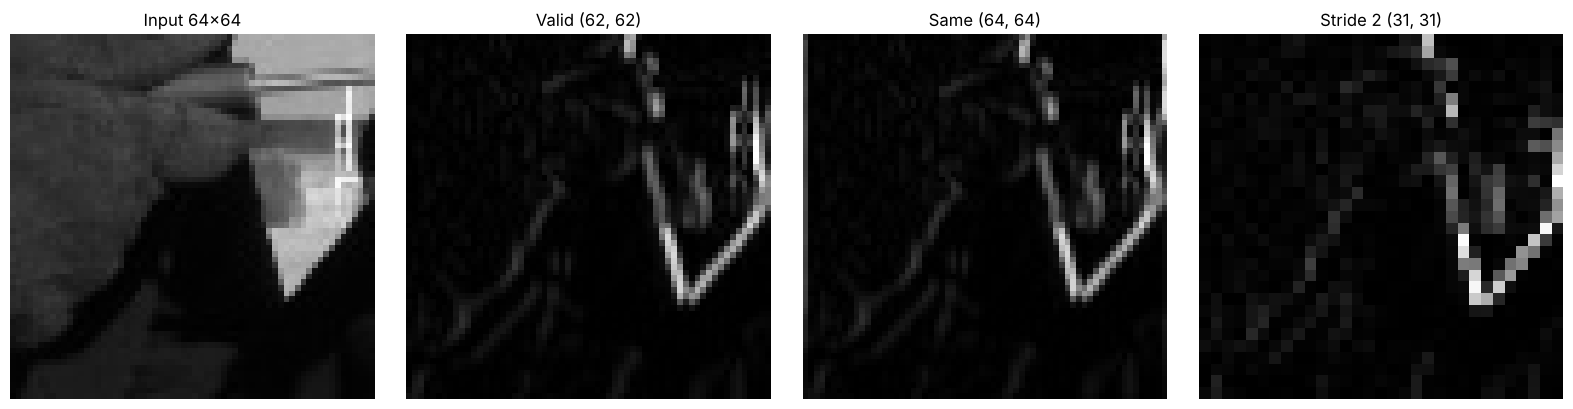

In [9]:
# Convolution from scratch -> shows valid / same / strided output sizes
def conv2d(img, kernel, padding='valid', stride=1):
    k = np.flipud(np.fliplr(kernel))            # true convolution flips the kernel
    kh, kw = k.shape
    if padding == 'same':                       # zero padding keeps size (stride 1)
        img = np.pad(img, ((kh // 2, kh // 2), (kw // 2, kw // 2)), mode='constant')
    H, W = img.shape
    out_h, out_w = (H - kh) // stride + 1, (W - kw) // stride + 1
    out = np.zeros((out_h, out_w))
    for i in range(out_h):
        for j in range(out_w):
            region = img[i * stride:i * stride + kh, j * stride:j * stride + kw]
            out[i, j] = np.sum(region * k)       # element-wise multiply + sum
    return out

small = image[200:264, 200:264].astype(np.float64)            # 64x64 crop
kernel = np.array([[1, 0, -1], [2, 0, -2], [1, 0, -1]], np.float64)
valid = conv2d(small, kernel, 'valid'); same = conv2d(small, kernel, 'same'); strided = conv2d(small, kernel, 'valid', stride=2)
print('input', small.shape, '| valid', valid.shape, '| same', same.shape, '| valid+stride 2', strided.shape)
print('formula: out = (N - K + 2P) / S + 1  ->  (64-3+0)/2+1 =', (64 - 3) // 2 + 1)

# OpenCV equivalents: same-size output with a chosen border; 'valid' = crop the border; stride = subsample
same_zero = cv2.filter2D(small, -1, kernel, borderType=cv2.BORDER_CONSTANT)   # zero padding
same_reflect = cv2.filter2D(small, -1, kernel, borderType=cv2.BORDER_REFLECT)  # mirror padding
valid_cv = same_zero[1:-1, 1:-1]; strided_cv = valid_cv[::2, ::2]
print('filter2D (correlation) == conv with flipped kernel:', np.allclose(valid_cv, -valid))   # Sobel kernel is antisymmetric
show([small, np.abs(valid), np.abs(same), np.abs(strided)], ['Input 64x64', f'Valid {valid.shape}', f'Same {same.shape}', f'Stride 2 {strided.shape}'])

# C. Edge detection
* Gradient-based: **Sobel, Prewitt, Scharr** (edges where gradient magnitude is high)
* **LoG / Marr-Hildreth:** Gaussian then Laplacian; edges at **zero-crossings** of 2nd derivative
* **Canny (1986):** Gaussian smoothing → gradient (Sobel) → **non-maximum suppression** (thin) → **hysteresis** (T_high strong, between = weak kept if connected, below T_low rejected)

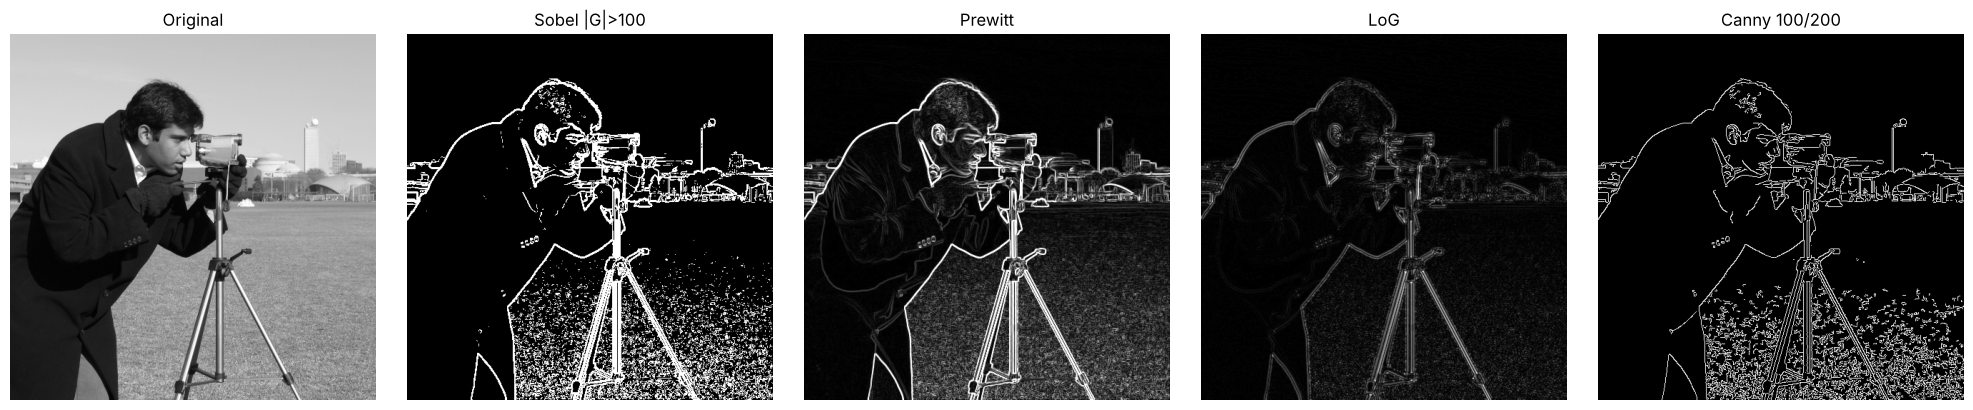

In [10]:
gm = np.sqrt(sobel_x**2 + sobel_y**2)
sobel_edges = (gm > 100).astype(np.uint8) * 255                                    # threshold gradient magnitude
px = cv2.filter2D(image.astype(np.float64), -1, np.array([[-1, 0, 1]] * 3, np.float64))   # Prewitt x
py = cv2.filter2D(image.astype(np.float64), -1, np.array([[-1, -1, -1], [0, 0, 0], [1, 1, 1]], np.float64))
prewitt = np.uint8(np.clip(np.sqrt(px**2 + py**2), 0, 255))
log = cv2.convertScaleAbs(cv2.Laplacian(cv2.GaussianBlur(image, (5, 5), 0), cv2.CV_64F, ksize=3))
canny = cv2.Canny(image, threshold1=100, threshold2=200)
show([image, sobel_edges, prewitt, log, canny], ['Original', 'Sobel |G|>100', 'Prewitt', 'LoG', 'Canny 100/200'])

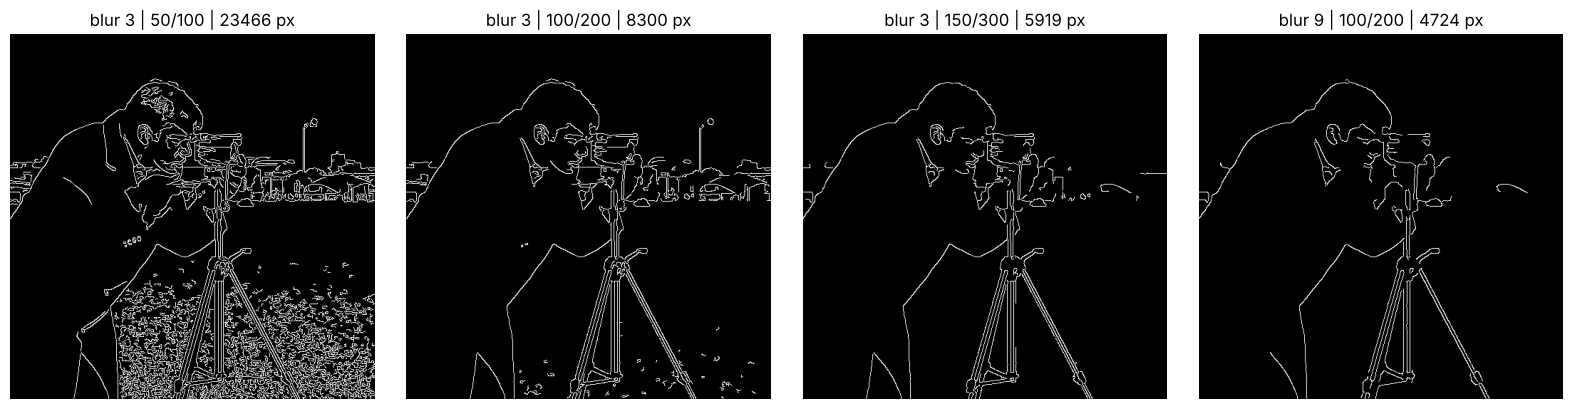

Lower thresholds -> more (noisy) edges; higher -> fewer, only strong edges; bigger blur -> loses fine detail.


In [11]:
# Canny parameter effects: sigma (blur) and the two thresholds
outs, titles = [], []
for blur_k, lo, hi in [(3, 50, 100), (3, 100, 200), (3, 150, 300), (9, 100, 200)]:
    src = cv2.GaussianBlur(image, (blur_k, blur_k), 0)
    e = cv2.Canny(src, lo, hi); outs.append(e); titles.append(f'blur {blur_k} | {lo}/{hi} | {int((e>0).sum())} px')
show(outs, titles)
print('Lower thresholds -> more (noisy) edges; higher -> fewer, only strong edges; bigger blur -> loses fine detail.')

## D. Corner detection (Harris & Shi-Tomasi)

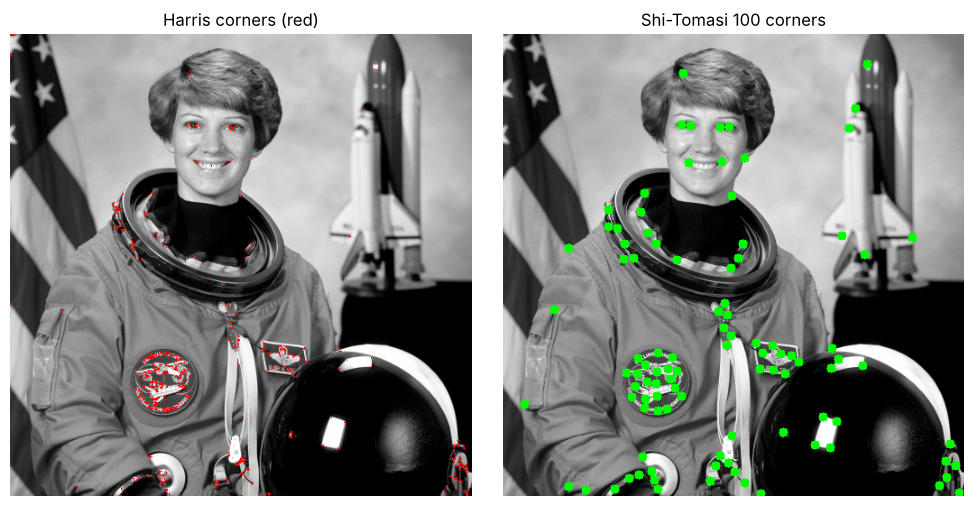

In [12]:
chk = cv2.cvtColor(data.astronaut(), cv2.COLOR_RGB2GRAY)
harris = cv2.cornerHarris(np.float32(chk), blockSize=2, ksize=3, k=0.04)
vis = cv2.cvtColor(chk, cv2.COLOR_GRAY2RGB); vis[harris > 0.01 * harris.max()] = [255, 0, 0]
pts = cv2.goodFeaturesToTrack(chk, maxCorners=100, qualityLevel=0.01, minDistance=10)
vis2 = cv2.cvtColor(chk, cv2.COLOR_GRAY2RGB)
for p in pts.astype(int): cv2.circle(vis2, tuple(p.ravel()), 5, (0, 255, 0), -1)
show([vis, vis2], ['Harris corners (red)', 'Shi-Tomasi 100 corners'], size=5)

# E. Manual Task — Texture Analysis for Material Classification (wood, metal, fabric)
**Technique 1 – LBP histogram:** compares each pixel with its circular neighbours, codes the pattern as a binary number and histograms the codes. Captures *micro-structure*: fabric weave (regular repeating codes), wood grain (edge/line codes), brushed metal (flat/streak codes).
**Technique 2 – Texture energy & contrast:** local sum-of-squares and local standard deviation. Captures *roughness and variation* — fabric = high contrast, brushed metal = low contrast, wood = medium with directional bands.
(Bonus: HED adds *directionality* — wood grain and metal streaks have dominant directions, weave has two.)

Approach: cut each material into 64×64 patches → feature vector per patch → nearest-centroid classifier → accuracy.

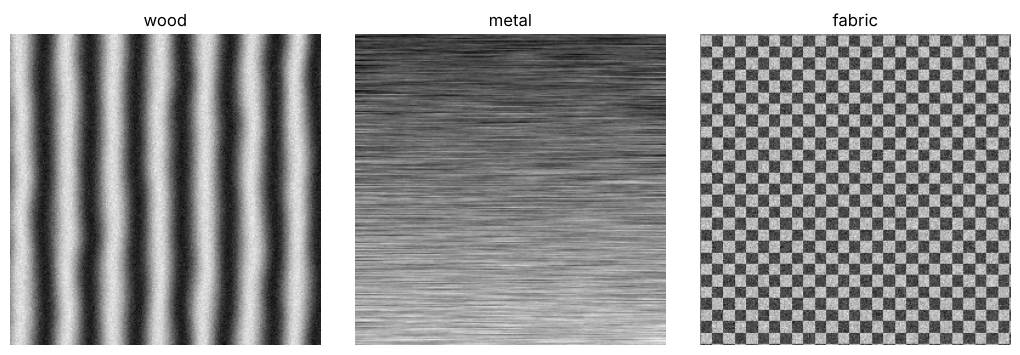

patches: 147 | test accuracy (nearest centroid): 100.0%
wood    mean energy=6.27  mean contrast=0.043
metal   mean energy=11.01  mean contrast=0.022
fabric  mean energy=7.30  mean contrast=0.144


In [13]:
from skimage.feature import local_binary_pattern
materials = ['wood', 'metal', 'fabric']
imgs = {m: cv2.imread(f'data/{m}.png', cv2.IMREAD_GRAYSCALE) for m in materials}
show([imgs[m] for m in materials], materials, size=3.5)

def features(patch):
    lbp = local_binary_pattern(patch, 8, 1, method='uniform')
    h, _ = np.histogram(lbp, bins=np.arange(11), range=(0, 10)); h = h / h.sum()
    e, c = texture_energy_contrast(patch, 5)
    gx = cv2.Sobel(patch, cv2.CV_64F, 1, 0); gy = cv2.Sobel(patch, cv2.CV_64F, 0, 1)
    ang = (np.degrees(np.arctan2(gy, gx)) + 180) % 180
    hed, _ = np.histogram(ang, bins=6, range=(0, 180), weights=np.hypot(gx, gy)); hed = hed / (hed.sum() + 1e-9)
    return np.concatenate([h, [e.mean() / 25, c.mean() * 4], hed])   # LBP(10) + energy/contrast(2) + HED(6)

X, y = [], []
for label, m in enumerate(materials):
    im = imgs[m]
    for r in range(0, 256 - 63, 32):
        for cidx in range(0, 256 - 63, 32):
            X.append(features(im[r:r + 64, cidx:cidx + 64])); y.append(label)
X, y = np.array(X), np.array(y)
idx = np.random.default_rng(0).permutation(len(y)); split = len(y) // 2
tr, te = idx[:split], idx[split:]
centroids = np.array([X[tr][y[tr] == k].mean(axis=0) for k in range(3)])
pred = np.argmin(((X[te][:, None, :] - centroids[None]) ** 2).sum(-1), axis=1)
print(f'patches: {len(y)} | test accuracy (nearest centroid): {np.mean(pred == y[te]):.1%}')
for k, m in enumerate(materials):
    e, c = texture_energy_contrast(imgs[m], 5); print(f'{m:7s} mean energy={e.mean():.2f}  mean contrast={c.mean():.3f}')

**Advantages & limitations (write this):**
| Technique | Advantages | Limitations |
|---|---|---|
| LBP | Simple, fast; invariant to monotonic lighting changes; rotation-invariant with `uniform`; strong for fine repeating textures (fabric) | Sensitive to noise on flat regions; small radius misses coarse textures (wood grain) unless multi-scale; no colour |
| Energy & Contrast | Very cheap; intuitive roughness measure; good at separating smooth (metal) vs rough (fabric) | Not rotation/scale aware; depends on illumination and window size; different textures can share the same energy |
| HED / HOG | Captures directionality (grain, streaks) | Rotating the sample changes the histogram unless orientation-normalised |